<div style="background: linear-gradient(90deg, #4da6ff, #0059b3); padding:20px; text-align:center; border-radius:10px;">
    <span style="color:white; font-size:28px; font-weight:bold;">
      DETECTER LES FAUX BILLETS AVEC PYTHON
    </span>
</div>

<div style="background: linear-gradient(90deg, #66c2ff, #004080); padding:12px; text-align:center; border-radius:8px; margin-top:10px;"> 
    <span style="color:white; font-size:20px; font-weight:bold;">
        Étape 1 - Importation des librairies et chargement des fichiers
    </span>
</div>

<div style="text-align:center; margin-top:8px; margin-bottom:8px;">
    <span style="color:white; font-size:18px; font-weight:normal;">
        1.1 - importation des librairies
    </span>
</div>

In [1]:
#importation de la librairie pandas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tabulate import tabulate
from IPython.display import display
import seaborn as sns
from datetime import datetime
#Importation de la librairie plotly express
import plotly.express as px
#Affichage de toutes les colonnes d'un dataframe
pd.set_option('display.max_columns', None)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (classification_report, 
                            confusion_matrix, 
                            accuracy_score,recall_score,f1_score,precision_score,
                            roc_auc_score)
import warnings
warnings.filterwarnings('ignore')
# Configuration des couleurs
couleurs = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD']
plt.rcParams['figure.figsize'] = (12, 6)

<div style="text-align:center; margin-top:8px; margin-bottom:8px;">
    <span style="color:white; font-size:18px; font-weight:normal;">
        1.2 - Chargement du fichier
    </span>
</div>

In [2]:
#Importation du fichier billets.csv
df_billets = pd. read_csv(r"C:\Users\QRSY8624\OneDrive - orange.com\Documents\CFA orange\Document_Alternant\Projet12\billets.csv", sep=";")
print(" Données chargées avec succès !")

 Données chargées avec succès !


In [3]:
# Exploration initiale
print(df_billets.shape)        
print(df_billets.head())
print(df_billets.info())
print(df_billets.describe())
print(df_billets.isnull().sum())  # Vérification des valeurs manquantes

(1500, 7)
   is_genuine  diagonal  height_left  height_right  margin_low  margin_up  \
0        True    171.81       104.86        104.95        4.52       2.89   
1        True    171.46       103.36        103.66        3.77       2.99   
2        True    172.69       104.48        103.50        4.40       2.94   
3        True    171.36       103.91        103.94        3.62       3.01   
4        True    171.73       104.28        103.46        4.04       3.48   

   length  
0  112.83  
1  113.09  
2  113.16  
3  113.51  
4  112.54  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   is_genuine    1500 non-null   bool   
 1   diagonal      1500 non-null   float64
 2   height_left   1500 non-null   float64
 3   height_right  1500 non-null   float64
 4   margin_low    1463 non-null   float64
 5   margin_up     1500 non-null   float64
 6   

In [4]:
# Vérification plus précise
print(f"Valeurs manquantes margin_low : {df_billets['margin_low'].isnull().sum()}")
print(f"Pourcentage : {df_billets['margin_low'].isnull().sum()/len(df_billets)*100:.2f}%")

# Analyse : les valeurs manquantes concernent-elles 
# plutôt les vrais ou les faux billets ?
print(df_billets[df_billets['margin_low'].isnull()]['is_genuine'].value_counts())

Valeurs manquantes margin_low : 37
Pourcentage : 2.47%
is_genuine
True     29
False     8
Name: count, dtype: int64


In [5]:
# Ce qu'on observe proportionnellement
print(f"Vrais billets total : 1000")
print(f"Faux billets total : 500")

# Proportion de manquants par classe
print(f"% manquants vrais billets : 29/1000 = 2.9%")
print(f"% manquants faux billets : 8/500 = 1.6%")

Vrais billets total : 1000
Faux billets total : 500
% manquants vrais billets : 29/1000 = 2.9%
% manquants faux billets : 8/500 = 1.6%


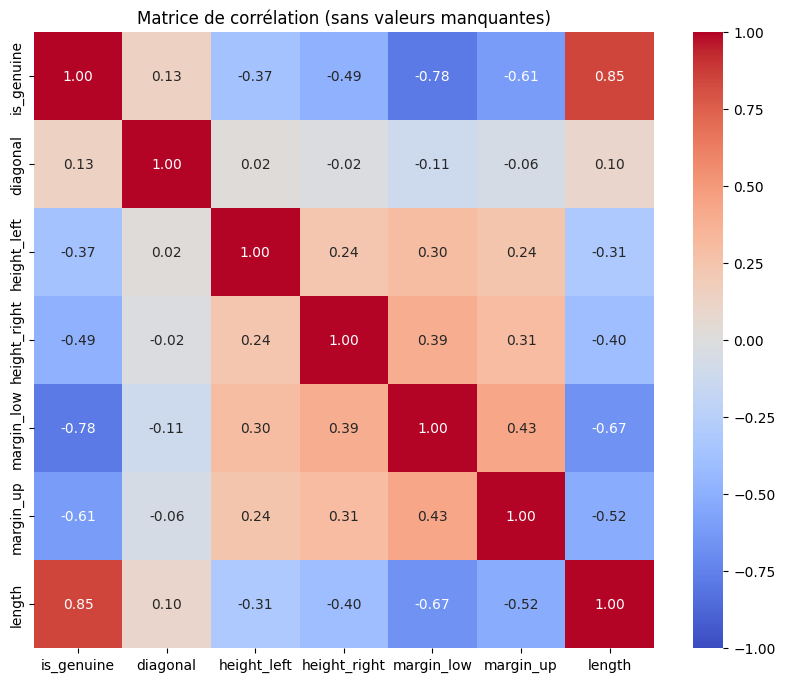

margin_low      1.000000
margin_up       0.431606
height_right    0.391085
height_left     0.302643
diagonal       -0.111534
length         -0.666753
is_genuine     -0.783032
Name: margin_low, dtype: float64


In [6]:
# Matrice de corrélation AVANT imputation
# (sur les lignes où margin_low n'est pas manquante)

plt.figure(figsize=(10,8))
sns.heatmap(
    df_billets.dropna().corr(numeric_only=True), 
    annot=True, 
    cmap='coolwarm',
    fmt='.2f',
    vmin=-1,    # ← AJOUT : borne minimale
    vmax=1,     # ← AJOUT : borne maximale
    center=0    # ← AJOUT : centre de l'échelle à 0
)
plt.title('Matrice de corrélation (sans valeurs manquantes)')
plt.show()

# Corrélations spécifiques avec margin_low
print(df_billets.dropna().corr(numeric_only=True)['margin_low']
      .sort_values(ascending=False))


In [7]:
# Variables les plus corrélées à margin_low :
#  length        : -0.67 (forte corrélation)
#  margin_up     : +0.43 (corrélation modérée)
#  height_right  : +0.39 (corrélation modérée)
#  height_left   : +0.30 (corrélation modérée)
#  diagonal      : -0.11 (trop faible, à exclure)

features_regression = ['length', 'margin_up', 
                        'height_right', 'height_left']


In [8]:
# Variables retenues pour l'imputation
features_regression = ['length', 'margin_up', 
                        'height_right', 'height_left']

# On exclut :
# - diagonal  : corrélation trop faible (-0.11)
# - is_genuine : c'est la variable cible, 
#                ne doit pas être utilisée pour l'imputation


In [9]:
from sklearn.linear_model import LinearRegression

# Variables retenues pour la régression
features_regression = ['length', 'margin_up', 
                        'height_right', 'height_left']

# Séparation des données complètes et manquantes
df_complet = df_billets[df_billets['margin_low'].notna()].copy()
df_manquant = df_billets[df_billets['margin_low'].isna()].copy()

print(f"Lignes complètes : {len(df_complet)}")   # 1463
print(f"Lignes manquantes : {len(df_manquant)}") # 37

# Entraînement du modèle de régression
reg = LinearRegression()
reg.fit(df_complet[features_regression], 
        df_complet['margin_low'])

# Score R² du modèle d'imputation
r2 = reg.score(df_complet[features_regression], 
               df_complet['margin_low'])
print(f"R² du modèle d'imputation : {r2:.4f}")

# Imputation des valeurs manquantes
df_billets.loc[df_billets['margin_low'].isna(), 'margin_low'] = reg.predict(
    df_manquant[features_regression]
)

# Vérification finale
print(f"\nValeurs manquantes après imputation : "
      f"{df_billets['margin_low'].isnull().sum()}")


Lignes complètes : 1463
Lignes manquantes : 37
R² du modèle d'imputation : 0.4748

Valeurs manquantes après imputation : 0


Distribution des classes :
is_genuine
True     1000
False     500
Name: count, dtype: int64

Pourcentage vrais billets : 66.67%
Pourcentage faux billets : 33.33%


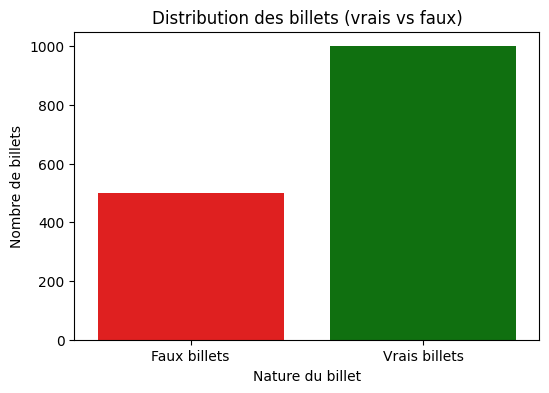

In [10]:
# Distribution des classes
print("Distribution des classes :")
print(df_billets['is_genuine'].value_counts())
print(f"\nPourcentage vrais billets : "
      f"{df_billets['is_genuine'].sum()/len(df_billets)*100:.2f}%")
print(f"Pourcentage faux billets : "
      f"{(~df_billets['is_genuine']).sum()/len(df_billets)*100:.2f}%")

# Visualisation
plt.figure(figsize=(6,4))
sns.countplot(x='is_genuine', data=df_billets,
              palette=['red', 'green'])
plt.title('Distribution des billets (vrais vs faux)')
plt.xlabel('Nature du billet')
plt.ylabel('Nombre de billets')
plt.xticks([0, 1], ['Faux billets', 'Vrais billets'])
plt.show()


In [11]:
# Statistiques descriptives globales
print("Statistiques descriptives :")
print(df_billets.describe().round(2))

# Statistiques par classe
print("\nStatistiques par classe :")
print(df_billets.groupby('is_genuine').describe().round(2))


Statistiques descriptives :
       diagonal  height_left  height_right  margin_low  margin_up   length
count   1500.00      1500.00       1500.00     1500.00    1500.00  1500.00
mean     171.96       104.03        103.92        4.48       3.15   112.68
std        0.31         0.30          0.33        0.66       0.23     0.87
min      171.04       103.14        102.82        2.98       2.27   109.49
25%      171.75       103.82        103.71        4.02       2.99   112.03
50%      171.96       104.04        103.92        4.31       3.14   112.96
75%      172.17       104.23        104.15        4.87       3.31   113.34
max      173.01       104.88        104.95        6.90       3.91   114.44

Statistiques par classe :
           diagonal                                                        \
              count    mean   std     min     25%     50%     75%     max   
is_genuine                                                                  
False         500.0  171.90  0.31  171.

In [12]:
# Pour voir les stats complètes de margin_low et margin_up
print(df_billets.groupby('is_genuine')[['margin_low', 
                                        'margin_up',
                                        'length']].describe().round(2))

           margin_low                                           margin_up  \
                count  mean   std   min   25%   50%   75%   max     count   
is_genuine                                                                  
False           500.0  5.21  0.55  3.82  4.84  5.18  5.59  6.90     500.0   
True           1000.0  4.12  0.32  2.98  3.91  4.12  4.34  5.04    1000.0   

                                                      length                \
            mean   std   min   25%   50%   75%   max   count    mean   std   
is_genuine                                                                   
False       3.35  0.18  2.92  3.22  3.35  3.47  3.91   500.0  111.63  0.62   
True        3.05  0.19  2.27  2.93  3.05  3.18  3.74  1000.0  113.20  0.36   

                                                    
               min     25%     50%     75%     max  
is_genuine                                          
False       109.49  111.20  111.63  112.03  113.85  
True       

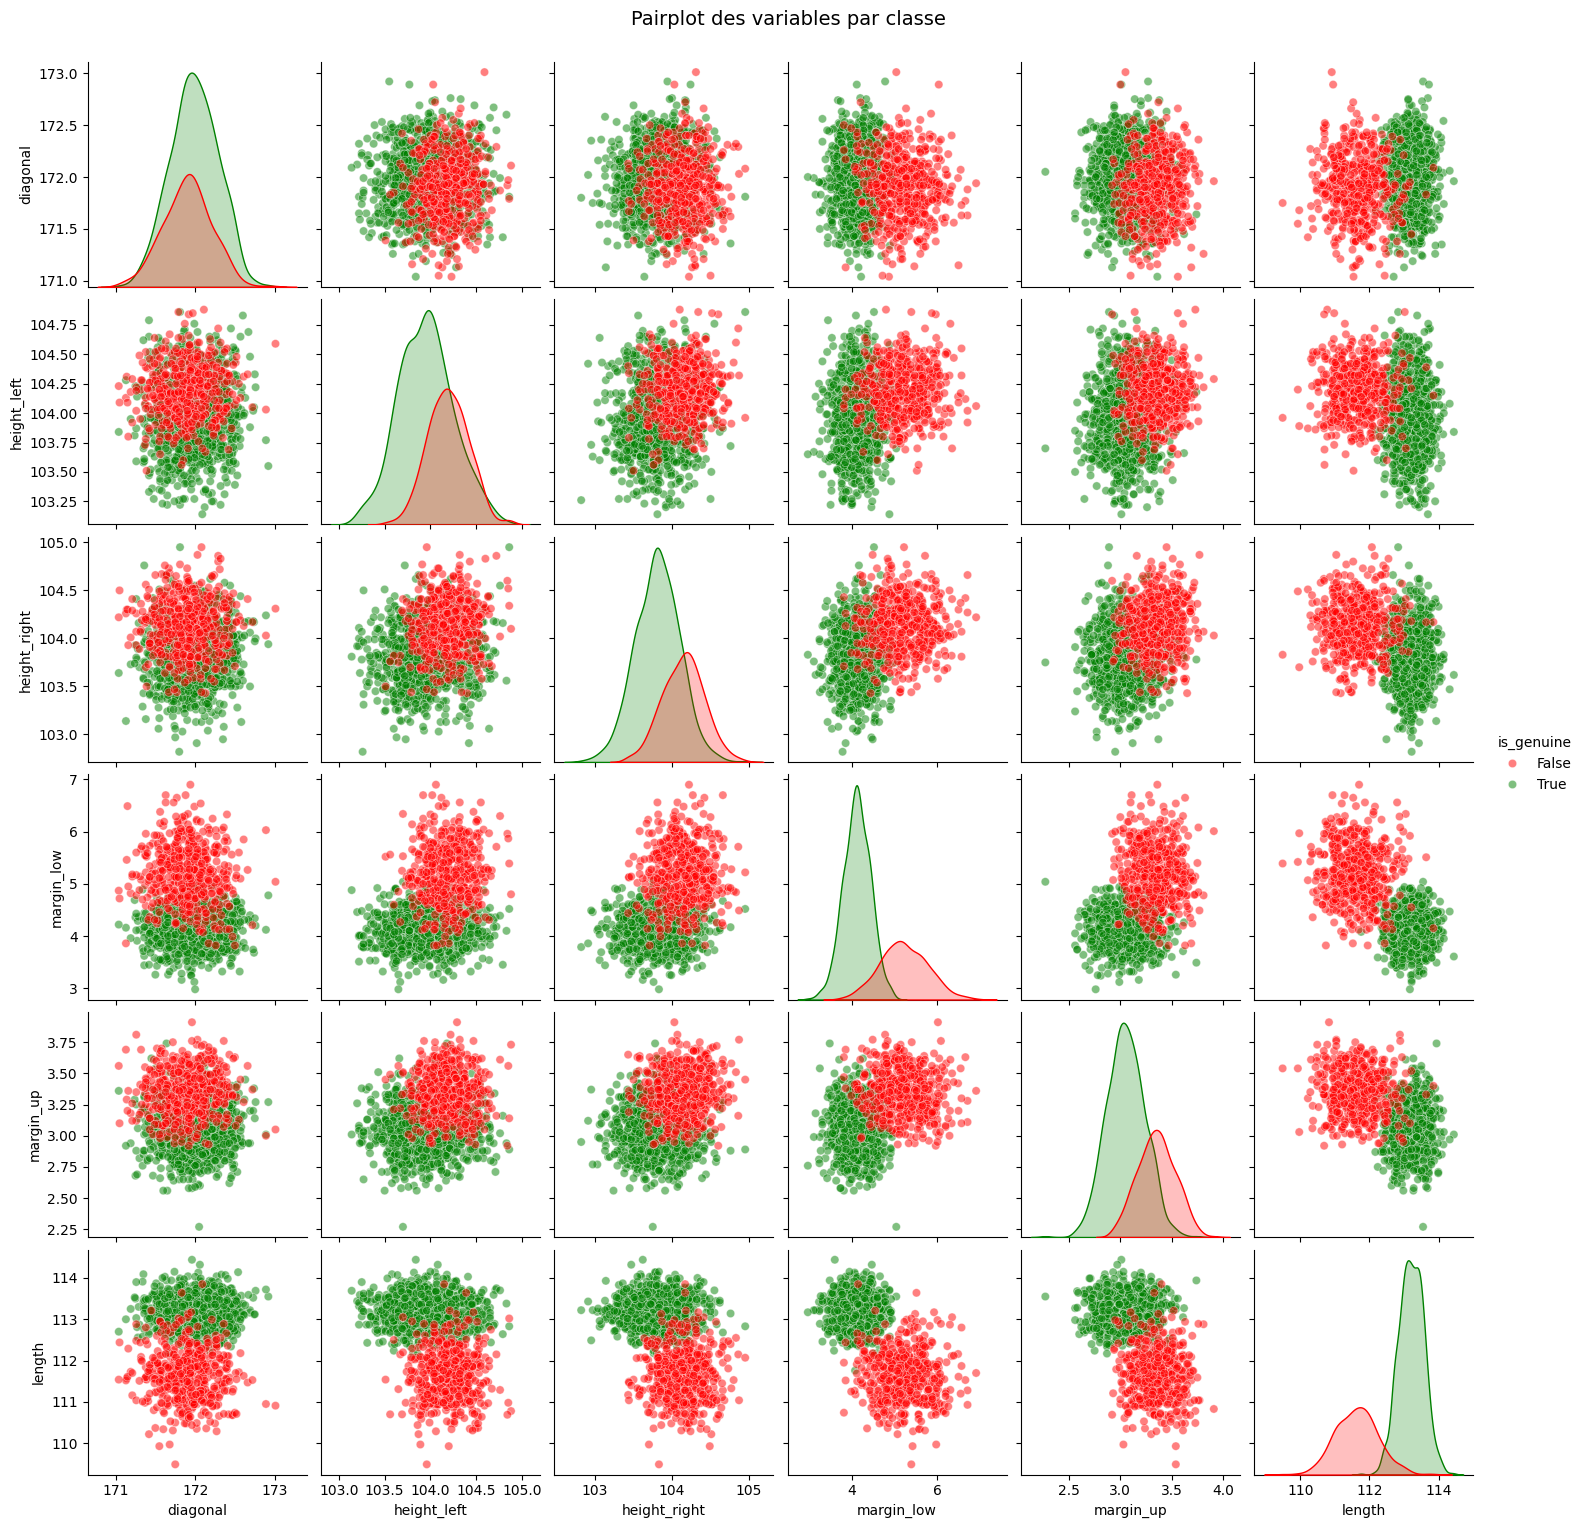

In [13]:
# Pairplot pour visualiser les relations entre variables
sns.pairplot(df_billets, 
             hue='is_genuine',
             palette={True: 'green', False: 'red'},
             vars=['diagonal', 'height_left', 'height_right',
                   'margin_low', 'margin_up', 'length'],
             plot_kws={'alpha': 0.5},
             diag_kind='kde')  # Distribution sur la diagonale

plt.suptitle('Pairplot des variables par classe', 
             y=1.02, fontsize=14)
plt.show()


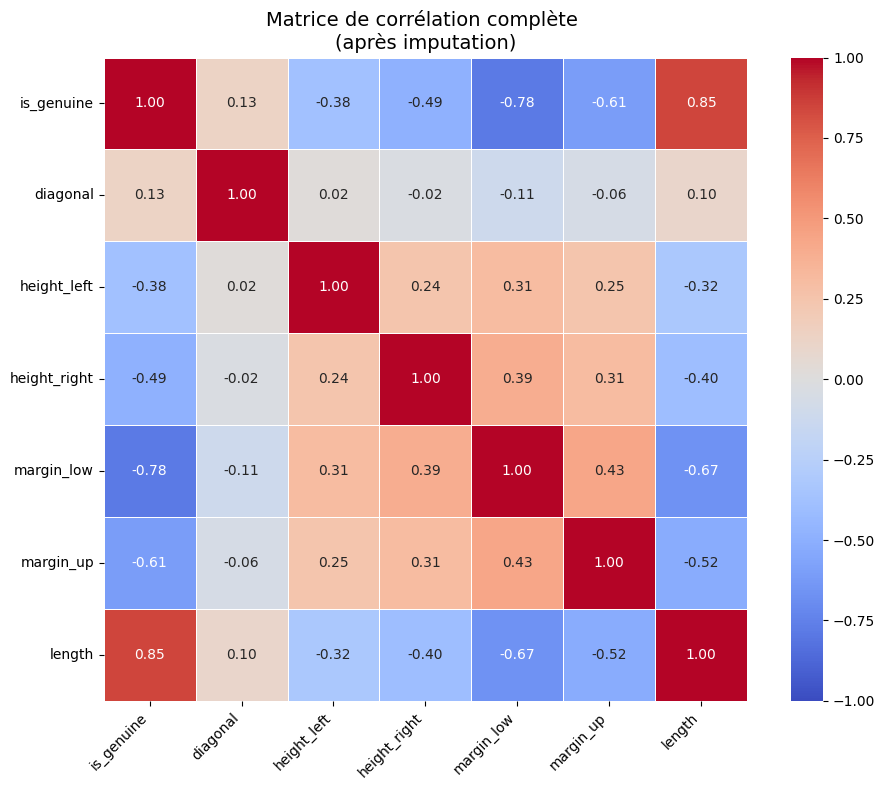

Corrélations avec is_genuine :
is_genuine      1.000000
length          0.849285
diagonal        0.132756
height_left    -0.379833
height_right   -0.485092
margin_up      -0.606262
margin_low     -0.783435
Name: is_genuine, dtype: float64


In [14]:
# ============================================
# MATRICE DE CORRÉLATION COMPLÈTE
# (après imputation des valeurs manquantes)
# ============================================

plt.figure(figsize=(10,8))
sns.heatmap(
    df_billets.corr(numeric_only=True), 
    annot=True, 
    cmap='coolwarm',
    fmt='.2f',
    vmin=-1,
    vmax=1,
    center=0,
    square=True,        # ← Cases carrées
    linewidths=0.5,     # ← Séparation entre cases
    linecolor='white'   # ← Couleur des séparations
)
plt.title('Matrice de corrélation complète \n(après imputation)', 
          fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ============================================
# CORRÉLATIONS AVEC LA VARIABLE CIBLE
# ============================================
print("=" * 50)
print("Corrélations avec is_genuine :")
print("=" * 50)
print(df_billets.corr(numeric_only=True)['is_genuine']
      .sort_values(ascending=False))


In [15]:
# ============================================
# 1. SÉPARATION X / y
# ============================================
X = df_billets[['diagonal', 'height_left', 'height_right',
                'margin_low', 'margin_up', 'length']]

y = df_billets['is_genuine']

print(" Séparation X / y :")
print(f"→ X (variables explicatives) : {X.shape}")
print(f"→ y (variable cible)         : {y.shape}")
print(f"\n→ Répartition des classes :")
print(y.value_counts())
print(f"\n→ Pourcentage :")
print(y.value_counts(normalize=True).round(2) * 100)


 Séparation X / y :
→ X (variables explicatives) : (1500, 6)
→ y (variable cible)         : (1500,)

→ Répartition des classes :
is_genuine
True     1000
False     500
Name: count, dtype: int64

→ Pourcentage :
is_genuine
True     67.0
False    33.0
Name: proportion, dtype: float64


In [16]:
# ============================================
# 2. TRAIN / TEST SPLIT
# ============================================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% pour le test
    random_state=42,    # Reproductibilité
    stratify=y          # Garder les proportions
)

print(" Train / Test Split :")
print(f"→ X_train : {X_train.shape}")
print(f"→ X_test  : {X_test.shape}")
print(f"→ y_train : {y_train.shape}")
print(f"→ y_test  : {y_test.shape}")
print(f"\n→ Répartition train :")
print(y_train.value_counts())
print(f"\n→ Répartition test :")
print(y_test.value_counts())


 Train / Test Split :
→ X_train : (1200, 6)
→ X_test  : (300, 6)
→ y_train : (1200,)
→ y_test  : (300,)

→ Répartition train :
is_genuine
True     800
False    400
Name: count, dtype: int64

→ Répartition test :
is_genuine
True     200
False    100
Name: count, dtype: int64


In [17]:
# ============================================
# 3. NORMALISATION
# ============================================
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# On FIT sur le train UNIQUEMENT
# On TRANSFORME train et test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(" Normalisation (StandardScaler) :")
print(f"\n→ Moyenne avant scaling (X_train) :")
print(X_train.mean().round(2))
print(f"\n→ Moyenne après scaling (X_train) :")
print(pd.DataFrame(X_train_scaled, 
      columns=X.columns).mean().round(2))
print(f"\n→ Écart-type après scaling (X_train) :")
print(pd.DataFrame(X_train_scaled, 
      columns=X.columns).std().round(2))


 Normalisation (StandardScaler) :

→ Moyenne avant scaling (X_train) :
diagonal        171.96
height_left     104.03
height_right    103.92
margin_low        4.49
margin_up         3.15
length          112.67
dtype: float64

→ Moyenne après scaling (X_train) :
diagonal        0.0
height_left    -0.0
height_right    0.0
margin_low      0.0
margin_up       0.0
length         -0.0
dtype: float64

→ Écart-type après scaling (X_train) :
diagonal        1.0
height_left     1.0
height_right    1.0
margin_low      1.0
margin_up       1.0
length          1.0
dtype: float64


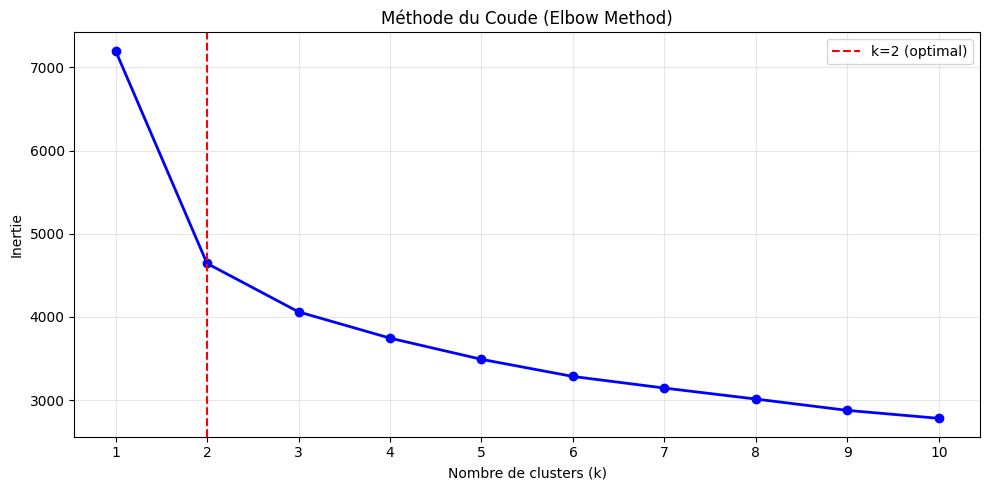

 Inertie par nombre de clusters :
→ k=1 : 7200.00
→ k=2 : 4643.27
→ k=3 : 4061.56
→ k=4 : 3746.05
→ k=5 : 3491.10
→ k=6 : 3285.32
→ k=7 : 3145.77
→ k=8 : 3013.79
→ k=9 : 2877.63
→ k=10 : 2781.89


In [18]:
# ============================================
# 1. MÉTHODE DU COUDE (Elbow Method)
# Pour trouver le nombre optimal de clusters
# ============================================
from sklearn.cluster import KMeans

inerties = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, 
                    random_state=42,
                    n_init=10)
    kmeans.fit(X_train_scaled)
    inerties.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(K, inerties, 'bo-', linewidth=2)
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Inertie')
plt.title('Méthode du Coude (Elbow Method)')
plt.xticks(K)
plt.grid(True, alpha=0.3)
plt.axvline(x=2, color='red', 
            linestyle='--', 
            label='k=2 (optimal)')
plt.legend()
plt.tight_layout()
plt.show()

print(" Inertie par nombre de clusters :")
for k, inertie in zip(K, inerties):
    print(f"→ k={k} : {inertie:.2f}")


In [19]:
# ============================================
# 2. ENTRAÎNEMENT K-MEANS AVEC k=2
# ============================================
kmeans = KMeans(n_clusters=2, 
                random_state=42,
                n_init=10)

kmeans.fit(X_train_scaled)

# Prédictions
kmeans_train_labels = kmeans.labels_
kmeans_test_labels  = kmeans.predict(X_test_scaled)

print(" K-means entraîné avec k=2 !")
print(f"\n→ Répartition des clusters (train) :")
unique, counts = np.unique(kmeans_train_labels, 
                           return_counts=True)
for u, c in zip(unique, counts):
    print(f"   Cluster {u} : {c} billets")


 K-means entraîné avec k=2 !

→ Répartition des clusters (train) :
   Cluster 0 : 394 billets
   Cluster 1 : 806 billets


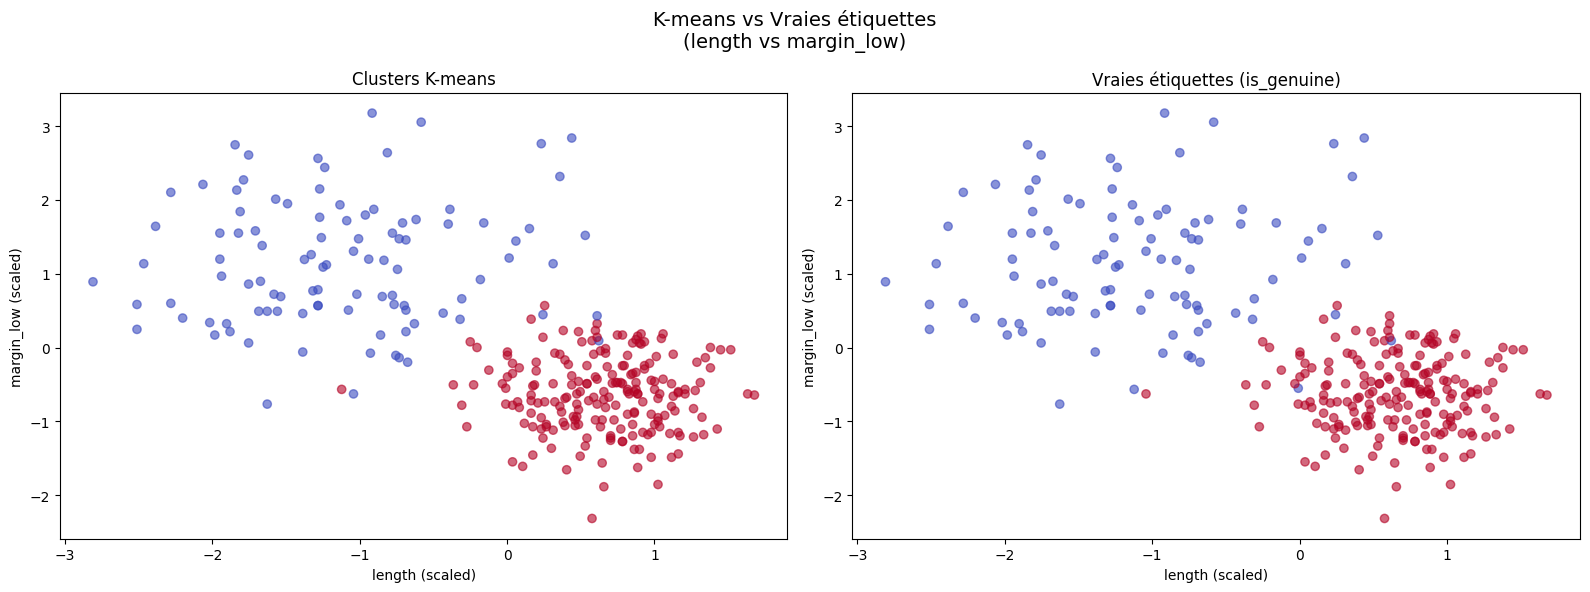

In [20]:
# ============================================
# 3. VISUALISATION DES CLUSTERS
# (sur les 2 meilleures variables)
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graphique 1 : Clusters K-means
axes[0].scatter(
    X_test_scaled[:, 5],  # length
    X_test_scaled[:, 3],  # margin_low
    c=kmeans_test_labels,
    cmap='coolwarm',
    alpha=0.6
)
axes[0].set_xlabel('length (scaled)')
axes[0].set_ylabel('margin_low (scaled)')
axes[0].set_title('Clusters K-means')

# Graphique 2 : Vraies étiquettes
axes[1].scatter(
    X_test_scaled[:, 5],  # length
    X_test_scaled[:, 3],  # margin_low
    c=y_test.astype(int),
    cmap='coolwarm',
    alpha=0.6
)
axes[1].set_xlabel('length (scaled)')
axes[1].set_ylabel('margin_low (scaled)')
axes[1].set_title('Vraies étiquettes (is_genuine)')

plt.suptitle('K-means vs Vraies étiquettes\n'
             '(length vs margin_low)', 
             fontsize=14)
plt.tight_layout()
plt.show()


In [21]:
# ============================================
# 4. ÉVALUATION DES CLUSTERS
# ============================================
from sklearn.metrics import (adjusted_rand_score,
                             silhouette_score,
                             confusion_matrix,
                             classification_report)

# Score de Silhouette
silhouette = silhouette_score(X_test_scaled, 
                              kmeans_test_labels)

# Adjusted Rand Index
ari = adjusted_rand_score(y_test, 
                          kmeans_test_labels)

print("=" * 50)
print(" ÉVALUATION K-MEANS :")
print("=" * 50)
print(f"→ Score de Silhouette : {silhouette:.4f}")
print(f"→ Adjusted Rand Index : {ari:.4f}")
print(f"\n→ Centres des clusters :")
centers = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=X.columns
)
print(centers.round(3))


 ÉVALUATION K-MEANS :
→ Score de Silhouette : 0.3337
→ Adjusted Rand Index : 0.9466

→ Centres des clusters :
   diagonal  height_left  height_right  margin_low  margin_up  length
0    -0.207        0.555         0.720       1.121      0.872  -1.214
1     0.101       -0.271        -0.352      -0.548     -0.426   0.593


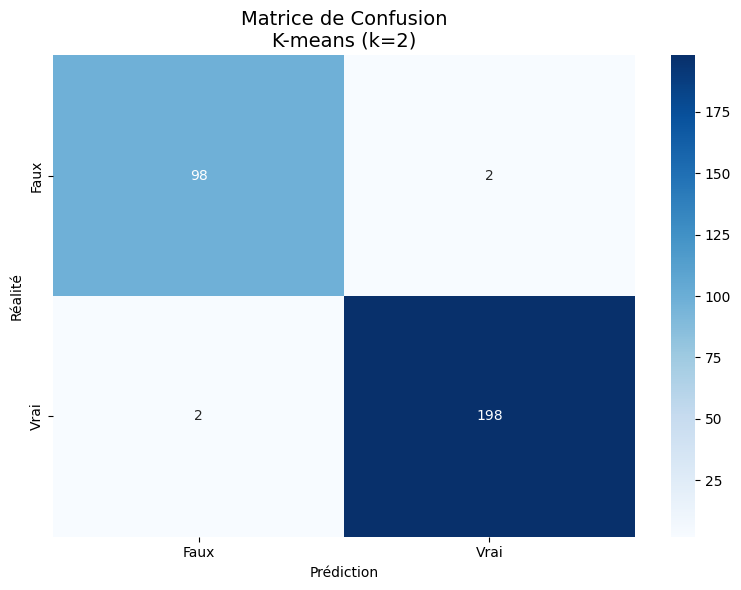

 MÉTRIQUES K-MEANS :
→ Accuracy  : 0.9867  (98.67%)
→ Precision : 0.9900 (99.00%)
→ Recall    : 0.9900  (99.00%)
→ F1-Score  : 0.9900  (99.00%)

→ Détail de la matrice :
   Vrais Positifs  (VP) : 198
   Vrais Négatifs  (VN) : 98
   Faux Positifs   (FP) : 2
   Faux Négatifs   (FN) : 2

→ Rapport complet :
              precision    recall  f1-score   support

       False       0.98      0.98      0.98       100
        True       0.99      0.99      0.99       200

    accuracy                           0.99       300
   macro avg       0.98      0.98      0.98       300
weighted avg       0.99      0.99      0.99       300



In [22]:
# Étape 3 : Matrice de confusion
cm_kmeans = confusion_matrix(
    y_test,
    kmeans_test_labels
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_kmeans,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Faux', 'Vrai'],
    yticklabels=['Faux', 'Vrai']
)
plt.title('Matrice de Confusion\nK-means (k=2)',
          fontsize=14)
plt.ylabel('Réalité')
plt.xlabel('Prédiction')
plt.tight_layout()
plt.show()

# Étape 4 : Métriques
accuracy_km  = accuracy_score(y_test, 
                               kmeans_test_labels)
precision_km = precision_score(y_test, 
                                kmeans_test_labels)
recall_km    = recall_score(y_test, 
                             kmeans_test_labels)
f1_km        = f1_score(y_test, 
                         kmeans_test_labels)

print("=" * 50)
print(" MÉTRIQUES K-MEANS :")
print("=" * 50)
print(f"→ Accuracy  : {accuracy_km:.4f}  "
      f"({accuracy_km*100:.2f}%)")
print(f"→ Precision : {precision_km:.4f} "
      f"({precision_km*100:.2f}%)")
print(f"→ Recall    : {recall_km:.4f}  "
      f"({recall_km*100:.2f}%)")
print(f"→ F1-Score  : {f1_km:.4f}  "
      f"({f1_km*100:.2f}%)")
print(f"\n→ Détail de la matrice :")
print(f"   Vrais Positifs  (VP) : {cm_kmeans[1,1]}")
print(f"   Vrais Négatifs  (VN) : {cm_kmeans[0,0]}")
print(f"   Faux Positifs   (FP) : {cm_kmeans[0,1]}")
print(f"   Faux Négatifs   (FN) : {cm_kmeans[1,0]}")
print(f"\n→ Rapport complet :")
print(classification_report(y_test, 
                            kmeans_test_labels))


In [23]:
# ============================================
# RECALL DÉTAILLÉ K-MEANS
# ============================================

# 1. Vérification de la correspondance
print("=" * 50)
print("Vérification correspondance :")
print("=" * 50)
crosstab = pd.crosstab(
    kmeans_test_labels,
    y_test,
    rownames=['Cluster K-means'],
    colnames=['is_genuine']
)
print(crosstab)

# 2. Conversion en booléen
kmeans_bool = kmeans_test_labels.astype(bool)

# 3. Recall par classe
recall_faux_km = recall_score(
    y_test,
    kmeans_bool,
    pos_label=False
)

recall_vrai_km = recall_score(
    y_test,
    kmeans_bool,
    pos_label=True
)

# 4. Affichage des résultats
print("\n" + "=" * 50)
print(" RECALL DÉTAILLÉ K-MEANS :")
print("=" * 50)
print(f"→ Recall Faux billets  : {recall_faux_km:.4f} "
      f"({recall_faux_km*100:.2f}%)")
print(f"→ Recall Vrais billets : {recall_vrai_km:.4f} "
      f"({recall_vrai_km*100:.2f}%)")
print(f"\n Interprétation Business :")
print(f"→ Faux billets manqués (FN) : "
      f"{cm_kmeans[0,1]}")
print(f"   Ces billets circulent "
      f"comme vrais !")

# 5. Tableau récapitulatif
resultats_km = pd.DataFrame({
    'Modèle'              : ['K-means'],
    'Accuracy'            : [accuracy_km],
    'Recall Global'       : [recall_km],
    'Recall Faux billets' : [recall_faux_km],
    'FN (billets manqués)': [cm_kmeans[0,1]]
})

print("\n" + "=" * 50)
print(" TABLEAU COMPARATIF (en cours) :")
print("=" * 50)
print(resultats_km.round(4).to_string(index=False))
print(f"\n Objectif : Recall Faux = 1.0000")
print(f"   (0 faux billet manqué !)")


Vérification correspondance :
is_genuine       False  True 
Cluster K-means              
0                   98      2
1                    2    198

 RECALL DÉTAILLÉ K-MEANS :
→ Recall Faux billets  : 0.9800 (98.00%)
→ Recall Vrais billets : 0.9900 (99.00%)

 Interprétation Business :
→ Faux billets manqués (FN) : 2
   Ces billets circulent comme vrais !

 TABLEAU COMPARATIF (en cours) :
 Modèle  Accuracy  Recall Global  Recall Faux billets  FN (billets manqués)
K-means    0.9867           0.99                 0.98                     2

 Objectif : Recall Faux = 1.0000
   (0 faux billet manqué !)


 Régression Logistique entraînée !


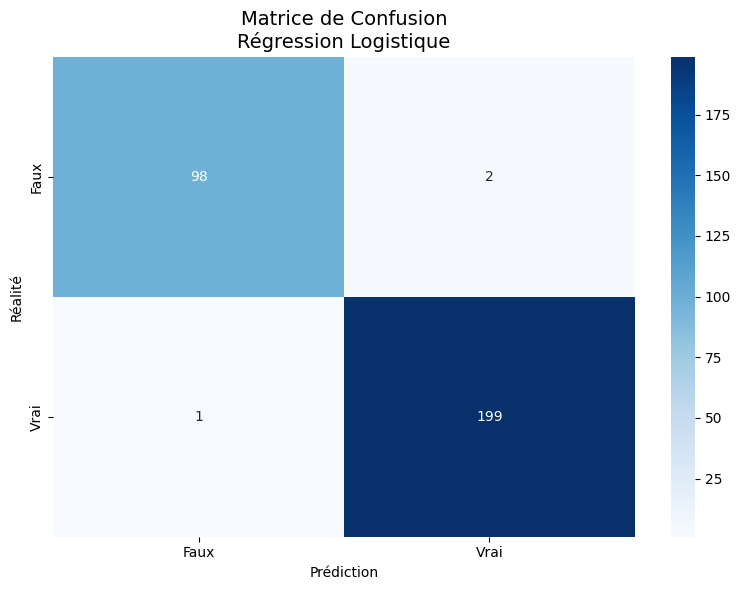


 MÉTRIQUES RÉGRESSION LOGISTIQUE :
→ Accuracy  : 0.9900 (99.00%)
→ Precision : 0.9900 (99.00%)
→ Recall    : 0.9950 (99.50%)
→ F1-Score  : 0.9925 (99.25%)

 RECALL DÉTAILLÉ :
→ Recall Faux billets  : 0.9800 (98.00%)
→ Recall Vrais billets : 0.9950 (99.50%)

 Interprétation Business :
→ Faux billets manqués (FN) : 2

 PROBABILITÉS (5 premiers billets) :
   Proba Faux  Proba Vrai  Prédiction  Réalité
0      0.0009      0.9991        True     True
1      1.0000      0.0000       False    False
2      1.0000      0.0000       False    False
3      0.3319      0.6681        True     True
4      0.0022      0.9978        True     True

 TABLEAU COMPARATIF (en cours) :
         Modèle  Accuracy  Recall Global  Recall Faux billets  FN (billets manqués)
        K-means    0.9867          0.990                 0.98                     2
Régression Log.    0.9900          0.995                 0.98                     2

 Objectif : Recall Faux = 1.0000
   (0 faux billet manqué !)


In [24]:
# ============================================
# RÉGRESSION LOGISTIQUE
# ============================================
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix,
                             classification_report,
                             accuracy_score,
                             precision_score,
                             recall_score,
                             f1_score)

# 1. Entraînement
log_reg = LogisticRegression(
    random_state=42,
    max_iter=1000
)
log_reg.fit(X_train_scaled, y_train)
print(" Régression Logistique entraînée !")

# 2. Prédictions
y_pred_lr  = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)

# 3. Matrice de confusion
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Faux', 'Vrai'],
    yticklabels=['Faux', 'Vrai']
)
plt.title('Matrice de Confusion\nRégression Logistique',
          fontsize=14)
plt.ylabel('Réalité')
plt.xlabel('Prédiction')
plt.tight_layout()
plt.show()

# 4. Métriques
accuracy_lr  = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr    = recall_score(y_test, y_pred_lr)
f1_lr        = f1_score(y_test, y_pred_lr)

# 5. Recall détaillé
recall_faux_lr = recall_score(
    y_test,
    y_pred_lr,
    pos_label=False
)
recall_vrai_lr = recall_score(
    y_test,
    y_pred_lr,
    pos_label=True
)

print("\n" + "=" * 50)
print(" MÉTRIQUES RÉGRESSION LOGISTIQUE :")
print("=" * 50)
print(f"→ Accuracy  : {accuracy_lr:.4f} "
      f"({accuracy_lr*100:.2f}%)")
print(f"→ Precision : {precision_lr:.4f} "
      f"({precision_lr*100:.2f}%)")
print(f"→ Recall    : {recall_lr:.4f} "
      f"({recall_lr*100:.2f}%)")
print(f"→ F1-Score  : {f1_lr:.4f} "
      f"({f1_lr*100:.2f}%)")

print("\n" + "=" * 50)
print(" RECALL DÉTAILLÉ :")
print("=" * 50)
print(f"→ Recall Faux billets  : {recall_faux_lr:.4f} "
      f"({recall_faux_lr*100:.2f}%)")
print(f"→ Recall Vrais billets : {recall_vrai_lr:.4f} "
      f"({recall_vrai_lr*100:.2f}%)")
print(f"\n Interprétation Business :")
print(f"→ Faux billets manqués (FN) : "
      f"{cm_lr[0,1]}")

# 6. Probabilités
print("\n" + "=" * 50)
print(" PROBABILITÉS (5 premiers billets) :")
print("=" * 50)
proba_df = pd.DataFrame({
    'Proba Faux' : y_proba_lr[:5, 0].round(4),
    'Proba Vrai' : y_proba_lr[:5, 1].round(4),
    'Prédiction' : y_pred_lr[:5],
    'Réalité'    : y_test.values[:5]
})
print(proba_df)

# 7. Mise à jour tableau comparatif
resultats = pd.DataFrame({
    'Modèle'              : ['K-means',
                             'Régression Log.'],
    'Accuracy'            : [accuracy_km,
                             accuracy_lr],
    'Recall Global'       : [recall_km,
                             recall_lr],
    'Recall Faux billets' : [recall_faux_km,
                             recall_faux_lr],
    'FN (billets manqués)': [cm_kmeans[0,1],
                             cm_lr[0,1]]
})

print("\n" + "=" * 50)
print(" TABLEAU COMPARATIF (en cours) :")
print("=" * 50)
print(resultats.round(4).to_string(index=False))
print(f"\n Objectif : Recall Faux = 1.0000")
print(f"   (0 faux billet manqué !)")


 RECHERCHE DU MEILLEUR K :


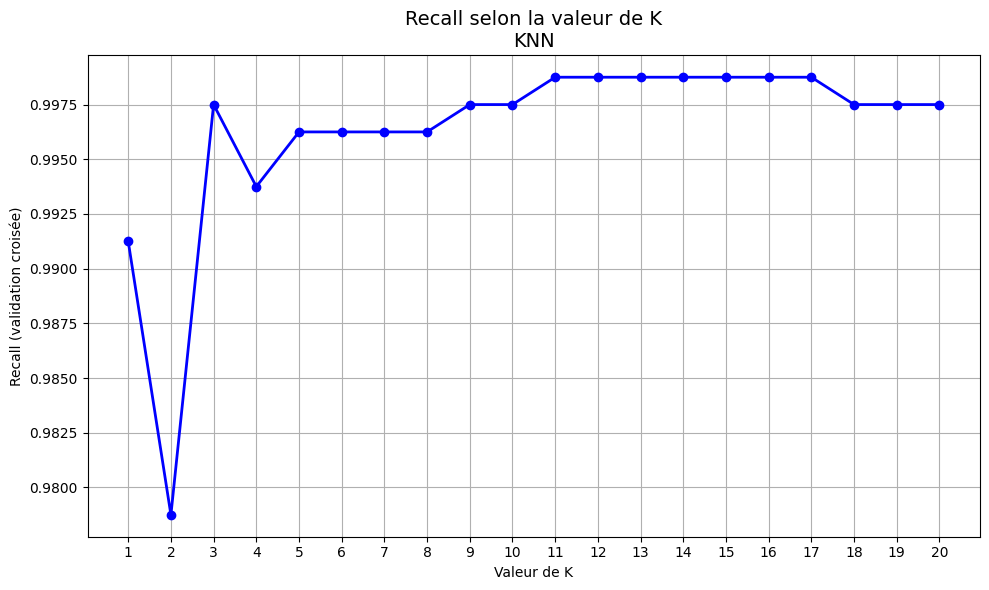

→ Meilleur K : 11
→ Recall     : 0.9988

 KNN entraîné avec K=11 !


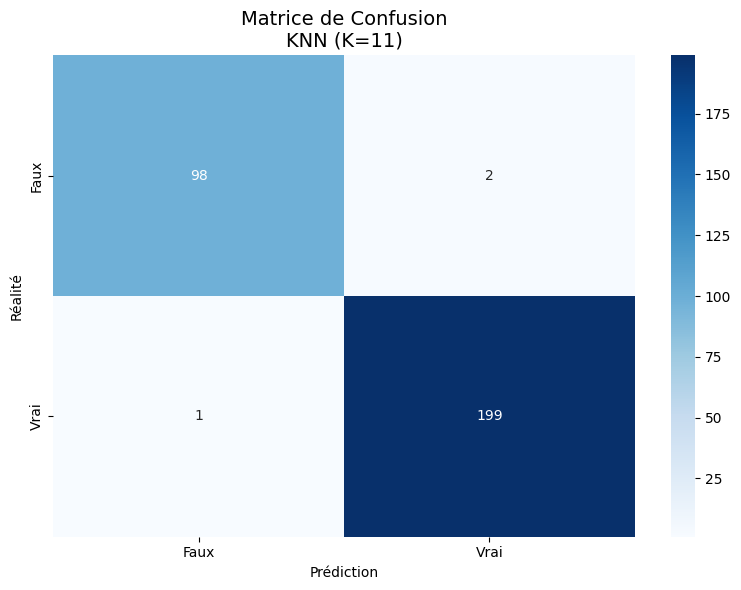


 MÉTRIQUES KNN :
→ Accuracy  : 0.9900 (99.00%)
→ Precision : 0.9900 (99.00%)
→ Recall    : 0.9950 (99.50%)
→ F1-Score  : 0.9925 (99.25%)

 RECALL DÉTAILLÉ :
→ Recall Faux billets  : 0.9800 (98.00%)
→ Recall Vrais billets : 0.9950 (99.50%)

 Interprétation Business :
→ Faux billets manqués (FN) : 2

 PROBABILITÉS (5 premiers billets) :
   Proba Faux  Proba Vrai  Prédiction  Réalité
0         0.0         1.0        True     True
1         1.0         0.0       False    False
2         1.0         0.0       False    False
3         0.0         1.0        True     True
4         0.0         1.0        True     True

 TABLEAU COMPARATIF (en cours) :
         Modèle  Accuracy  Recall Global  Recall Faux billets  FN (billets manqués)
        K-means    0.9867          0.990                 0.98                     2
Régression Log.    0.9900          0.995                 0.98                     2
            KNN    0.9900          0.995                 0.98                     2

 Objectif

In [25]:
# ============================================
# KNN (K-NEAREST NEIGHBORS)
# ============================================
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

# 1. Trouver le meilleur K
print("=" * 50)
print(" RECHERCHE DU MEILLEUR K :")
print("=" * 50)

k_scores = []
k_range  = range(1, 21)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(
        knn,
        X_train_scaled,
        y_train,
        cv=5,
        scoring='recall'
    )
    k_scores.append(scores.mean())

# Visualisation des scores
plt.figure(figsize=(10, 6))
plt.plot(k_range,
         k_scores,
         marker='o',
         color='blue',
         linewidth=2)
plt.title('Recall selon la valeur de K\nKNN',
          fontsize=14)
plt.xlabel('Valeur de K')
plt.ylabel('Recall (validation croisée)')
plt.xticks(k_range)
plt.grid(True)
plt.tight_layout()
plt.show()

# Meilleur K
best_k = k_range[k_scores.index(max(k_scores))]
print(f"→ Meilleur K : {best_k}")
print(f"→ Recall     : {max(k_scores):.4f}")

# 2. Entraînement avec le meilleur K
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)
print(f"\n KNN entraîné avec K={best_k} !")

# 3. Prédictions
y_pred_knn  = knn.predict(X_test_scaled)
y_proba_knn = knn.predict_proba(X_test_scaled)

# 4. Matrice de confusion
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_knn,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Faux', 'Vrai'],
    yticklabels=['Faux', 'Vrai']
)
plt.title(f'Matrice de Confusion\nKNN (K={best_k})',
          fontsize=14)
plt.ylabel('Réalité')
plt.xlabel('Prédiction')
plt.tight_layout()
plt.show()

# 5. Métriques
accuracy_knn  = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn    = recall_score(y_test, y_pred_knn)
f1_knn        = f1_score(y_test, y_pred_knn)

# 6. Recall détaillé
recall_faux_knn = recall_score(
    y_test,
    y_pred_knn,
    pos_label=False
)
recall_vrai_knn = recall_score(
    y_test,
    y_pred_knn,
    pos_label=True
)

print("\n" + "=" * 50)
print(" MÉTRIQUES KNN :")
print("=" * 50)
print(f"→ Accuracy  : {accuracy_knn:.4f} "
      f"({accuracy_knn*100:.2f}%)")
print(f"→ Precision : {precision_knn:.4f} "
      f"({precision_knn*100:.2f}%)")
print(f"→ Recall    : {recall_knn:.4f} "
      f"({recall_knn*100:.2f}%)")
print(f"→ F1-Score  : {f1_knn:.4f} "
      f"({f1_knn*100:.2f}%)")

print("\n" + "=" * 50)
print(" RECALL DÉTAILLÉ :")
print("=" * 50)
print(f"→ Recall Faux billets  : {recall_faux_knn:.4f} "
      f"({recall_faux_knn*100:.2f}%)")
print(f"→ Recall Vrais billets : {recall_vrai_knn:.4f} "
      f"({recall_vrai_knn*100:.2f}%)")
print(f"\n Interprétation Business :")
print(f"→ Faux billets manqués (FN) : "
      f"{cm_knn[0,1]}")

# 7. Probabilités
print("\n" + "=" * 50)
print(" PROBABILITÉS (5 premiers billets) :")
print("=" * 50)
proba_df_knn = pd.DataFrame({
    'Proba Faux' : y_proba_knn[:5, 0].round(4),
    'Proba Vrai' : y_proba_knn[:5, 1].round(4),
    'Prédiction' : y_pred_knn[:5],
    'Réalité'    : y_test.values[:5]
})
print(proba_df_knn)

# 8. Tableau comparatif mis à jour
resultats = pd.DataFrame({
    'Modèle'              : ['K-means',
                             'Régression Log.',
                             'KNN'],
    'Accuracy'            : [accuracy_km,
                             accuracy_lr,
                             accuracy_knn],
    'Recall Global'       : [recall_km,
                             recall_lr,
                             recall_knn],
    'Recall Faux billets' : [recall_faux_km,
                             recall_faux_lr,
                             recall_faux_knn],
    'FN (billets manqués)': [cm_kmeans[0,1],
                             cm_lr[0,1],
                             cm_knn[0,1]]
})

print("\n" + "=" * 50)
print(" TABLEAU COMPARATIF (en cours) :")
print("=" * 50)
print(resultats.round(4).to_string(index=False))
print(f"\n Objectif : Recall Faux = 1.0000")
print(f"   (0 faux billet manqué !)")


 RECHERCHE DES MEILLEURS PARAMÈTRES :
Fitting 5 folds for each of 36 candidates, totalling 180 fits

→ Meilleurs paramètres :
  {'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 100}
→ Meilleur Recall : 0.9975

 Random Forest entraîné !


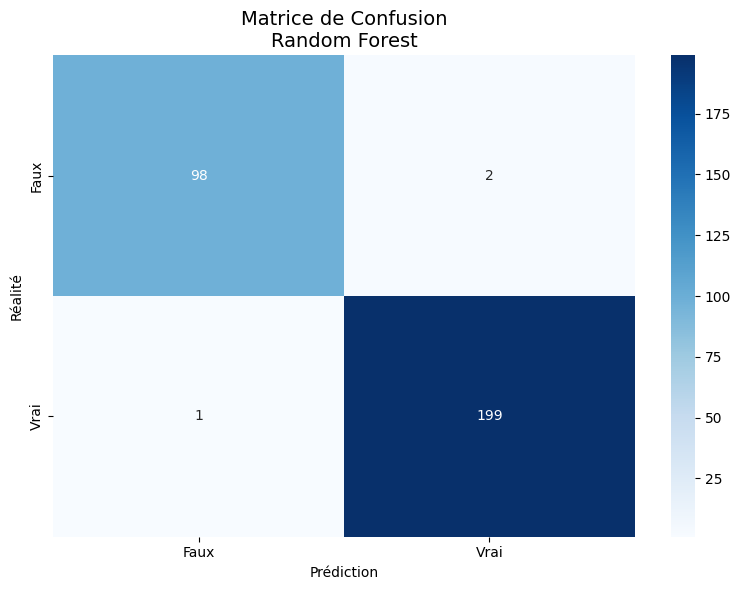


 MÉTRIQUES RANDOM FOREST :
→ Accuracy  : 0.9900 (99.00%)
→ Precision : 0.9900 (99.00%)
→ Recall    : 0.9950 (99.50%)
→ F1-Score  : 0.9925 (99.25%)

 RECALL DÉTAILLÉ :
→ Recall Faux billets  : 0.9800 (98.00%)
→ Recall Vrais billets : 0.9950 (99.50%)

 Interprétation Business :
→ Faux billets manqués (FN) : 2

 IMPORTANCE DES VARIABLES :


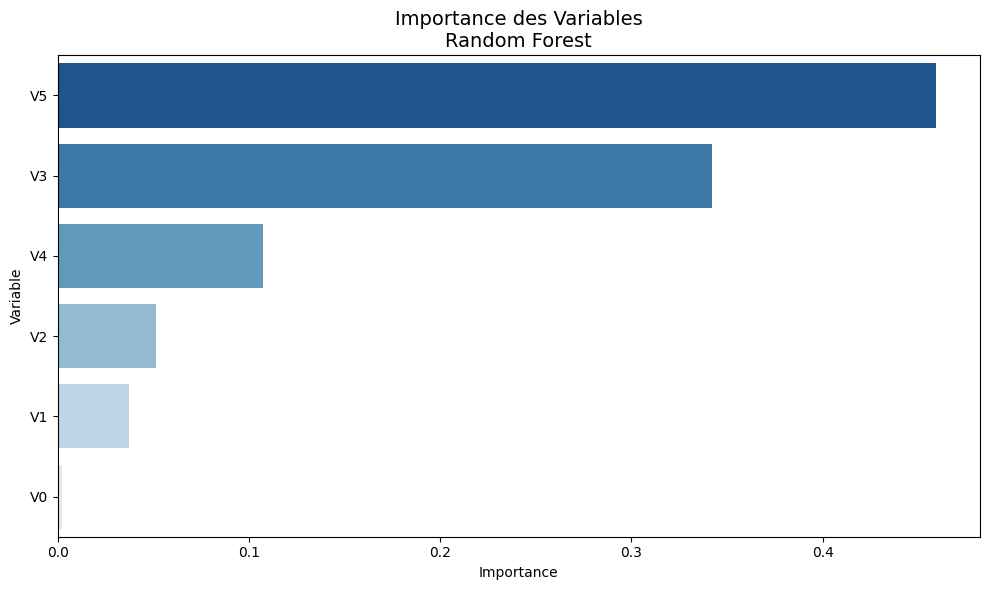

Variable  Importance
      V5      0.4593
      V3      0.3424
      V4      0.1072
      V2      0.0516
      V1      0.0372
      V0      0.0023

 PROBABILITÉS (5 premiers billets) :
   Proba Faux  Proba Vrai  Prédiction  Réalité
0      0.0360      0.9640        True     True
1      0.9733      0.0267       False    False
2      0.9800      0.0200       False    False
3      0.0840      0.9160        True     True
4      0.0620      0.9380        True     True

 TABLEAU COMPARATIF FINAL :
         Modèle  Accuracy  Recall Global  Recall Faux billets  FN (billets manqués)
        K-means    0.9867          0.990                 0.98                     2
Régression Log.    0.9900          0.995                 0.98                     2
            KNN    0.9900          0.995                 0.98                     2
  Random Forest    0.9900          0.995                 0.98                     2

 Objectif : Recall Faux = 1.0000
   (0 faux billet manqué !)


In [26]:
# ============================================
# RANDOM FOREST
# ============================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# 1. Recherche des meilleurs hyperparamètres
print("=" * 50)
print(" RECHERCHE DES MEILLEURS PARAMÈTRES :")
print("=" * 50)

param_grid = {
    'n_estimators' : [100, 200, 300],
    'max_depth'    : [3, 5, 10, None],
    'min_samples_split' : [2, 5, 10]
}

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train_scaled, y_train)

print(f"\n→ Meilleurs paramètres :")
print(f"  {grid_search.best_params_}")
print(f"→ Meilleur Recall : "
      f"{grid_search.best_score_:.4f}")

# 2. Entraînement avec les meilleurs paramètres
rf_best = grid_search.best_estimator_
print(f"\n Random Forest entraîné !")

# 3. Prédictions
y_pred_rf  = rf_best.predict(X_test_scaled)
y_proba_rf = rf_best.predict_proba(X_test_scaled)

# 4. Matrice de confusion
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Faux', 'Vrai'],
    yticklabels=['Faux', 'Vrai']
)
plt.title('Matrice de Confusion\nRandom Forest',
          fontsize=14)
plt.ylabel('Réalité')
plt.xlabel('Prédiction')
plt.tight_layout()
plt.show()

# 5. Métriques
accuracy_rf  = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf    = recall_score(y_test, y_pred_rf)
f1_rf        = f1_score(y_test, y_pred_rf)

# 6. Recall détaillé
recall_faux_rf = recall_score(
    y_test,
    y_pred_rf,
    pos_label=False
)
recall_vrai_rf = recall_score(
    y_test,
    y_pred_rf,
    pos_label=True
)

print("\n" + "=" * 50)
print(" MÉTRIQUES RANDOM FOREST :")
print("=" * 50)
print(f"→ Accuracy  : {accuracy_rf:.4f} "
      f"({accuracy_rf*100:.2f}%)")
print(f"→ Precision : {precision_rf:.4f} "
      f"({precision_rf*100:.2f}%)")
print(f"→ Recall    : {recall_rf:.4f} "
      f"({recall_rf*100:.2f}%)")
print(f"→ F1-Score  : {f1_rf:.4f} "
      f"({f1_rf*100:.2f}%)")

print("\n" + "=" * 50)
print(" RECALL DÉTAILLÉ :")
print("=" * 50)
print(f"→ Recall Faux billets  : {recall_faux_rf:.4f} "
      f"({recall_faux_rf*100:.2f}%)")
print(f"→ Recall Vrais billets : {recall_vrai_rf:.4f} "
      f"({recall_vrai_rf*100:.2f}%)")
print(f"\n Interprétation Business :")
print(f"→ Faux billets manqués (FN) : "
      f"{cm_rf[0,1]}")

# 7. Importance des variables
print("\n" + "=" * 50)
print(" IMPORTANCE DES VARIABLES :")
print("=" * 50)

feature_importance = pd.DataFrame({
    'Variable'   : X_train_scaled.columns 
                   if hasattr(X_train_scaled, 'columns')
                   else [f'V{i}' for i in 
                   range(X_train_scaled.shape[1])],
    'Importance' : rf_best.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Variable',
    palette='Blues_r'
)
plt.title('Importance des Variables\nRandom Forest',
          fontsize=14)
plt.tight_layout()
plt.show()

print(feature_importance.round(4).to_string(
    index=False))

# 8. Probabilités
print("\n" + "=" * 50)
print(" PROBABILITÉS (5 premiers billets) :")
print("=" * 50)
proba_df_rf = pd.DataFrame({
    'Proba Faux' : y_proba_rf[:5, 0].round(4),
    'Proba Vrai' : y_proba_rf[:5, 1].round(4),
    'Prédiction' : y_pred_rf[:5],
    'Réalité'    : y_test.values[:5]
})
print(proba_df_rf)

# 9. Tableau comparatif final
resultats = pd.DataFrame({
    'Modèle'              : ['K-means',
                             'Régression Log.',
                             'KNN',
                             'Random Forest'],
    'Accuracy'            : [accuracy_km,
                             accuracy_lr,
                             accuracy_knn,
                             accuracy_rf],
    'Recall Global'       : [recall_km,
                             recall_lr,
                             recall_knn,
                             recall_rf],
    'Recall Faux billets' : [recall_faux_km,
                             recall_faux_lr,
                             recall_faux_knn,
                             recall_faux_rf],
    'FN (billets manqués)': [cm_kmeans[0,1],
                             cm_lr[0,1],
                             cm_knn[0,1],
                             cm_rf[0,1]]
})

print("\n" + "=" * 50)
print(" TABLEAU COMPARATIF FINAL :")
print("=" * 50)
print(resultats.round(4).to_string(index=False))
print(f"\n Objectif : Recall Faux = 1.0000")
print(f"   (0 faux billet manqué !)")


In [27]:
# ============================================
# TABLEAU COMPARATIF FINAL - 4 ALGORITHMES
# ============================================
from sklearn.metrics import roc_auc_score

# AUC-ROC pour K-means
# (utilisation des distances aux centres)
kmeans_proba = kmeans.transform(X_test_scaled)
kmeans_scores = kmeans_proba[:, 0] / (
    kmeans_proba[:, 0] + kmeans_proba[:, 1]
)

results = pd.DataFrame({
    'Modèle'              : ['K-means',
                             'Régression Log.',
                             'KNN',
                             'Random Forest'],
    'Accuracy'            : [
        accuracy_km,
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_rf)
    ],
    'Precision'           : [
        precision_km,
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_rf)
    ],
    'Recall Global'       : [
        recall_km,
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_rf)
    ],
    'Recall Faux billets' : [
        recall_faux_km,
        recall_faux_lr,
        recall_faux_knn,
        recall_faux_rf
    ],
    'F1-Score'            : [
        f1_km,
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_rf)
    ],
    'AUC-ROC'             : [
        roc_auc_score(y_test, kmeans_scores),
        roc_auc_score(y_test, y_proba_lr[:,1]),
        roc_auc_score(y_test, y_proba_knn[:,1]),
        roc_auc_score(y_test, y_proba_rf[:,1])
    ],
    'FN (billets manqués)': [
        cm_kmeans[0,1],
        cm_lr[0,1],
        cm_knn[0,1],
        cm_rf[0,1]
    ]
})

# Tri par AUC-ROC décroissant
results_sorted = results.sort_values(
    'AUC-ROC',
    ascending=False
).round(4)

print("=" * 70)
print(" TABLEAU COMPARATIF FINAL - 4 ALGORITHMES :")
print("=" * 70)
print(results_sorted.to_string(index=False))
print("\n Objectif : Recall Faux = 1.0000")
print("   (0 faux billet manqué !)")

# Meilleur modèle
best_model = results_sorted.iloc[0]['Modèle']
best_auc   = results_sorted.iloc[0]['AUC-ROC']
print(f"\n Meilleur modèle : {best_model}")
print(f"   AUC-ROC         : {best_auc:.4f}")


 TABLEAU COMPARATIF FINAL - 4 ALGORITHMES :
         Modèle  Accuracy  Precision  Recall Global  Recall Faux billets  F1-Score  AUC-ROC  FN (billets manqués)
Régression Log.    0.9900       0.99          0.995                 0.98    0.9925   0.9995                     2
            KNN    0.9900       0.99          0.995                 0.98    0.9925   0.9994                     2
        K-means    0.9867       0.99          0.990                 0.98    0.9900   0.9992                     2
  Random Forest    0.9900       0.99          0.995                 0.98    0.9925   0.9992                     2

 Objectif : Recall Faux = 1.0000
   (0 faux billet manqué !)

 Meilleur modèle : Régression Log.
   AUC-ROC         : 0.9995


In [28]:
# ============================================
# Sauvegarder le modèle
# ============================================
import pickle

# Sauvegarder le modèle
with open('log_reg.pkl', 'wb') as f:
    pickle.dump(log_reg, f)

# Sauvegarder le scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print(" Modèle sauvegardé !")


 Modèle sauvegardé !
